## Analyze A/B Test Results

## Table of Contents
- [Introduction](#intro)
- [Part I - Probability](#probability)
- [Part II - A/B Test](#ab_test)
- [Part III - Regression](#regression)


<a id='intro'></a>
### Introduction

For this project, we try to understand the results of an A/B test run by an e-commerce website.  The goal is to help the company understand if they should implement the new page, keep the old page, or perhaps run the experiment longer to make their decision.

<a id='probability'></a>
#### Part I - Probability

To get started, let's import our libraries.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
random.seed(42)

In [2]:
df = pd.read_csv('ab_data.csv')
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
df.shape[0]

294478

In [4]:
df['user_id'].nunique()

290584

In [5]:
df.converted.mean()*100

11.96591935560551

In [6]:
#count the values of group and landing page columns first
df.group.value_counts(), df.landing_page.value_counts()

(treatment    147276
 control      147202
 Name: group, dtype: int64,
 old_page    147239
 new_page    147239
 Name: landing_page, dtype: int64)

In [7]:
#query the mismatched groups by grouping "treatment" with old page and "control" with new page
df_treatment = df.query('group == "treatment" & landing_page == "old_page"')

df_control = df.query('group == "control" & landing_page == "new_page"')

#adding the 2 numbers together to calculate how many times the new_page and treatment don't line up
df_treatment.shape[0] + df_control.shape[0] , df_treatment.group.count()

(3893, 1965)

In [8]:
df.isnull().any()

user_id         False
timestamp       False
group           False
landing_page    False
converted       False
dtype: bool

In [9]:
#remove the rows that don't match
df2 = df.drop(df_treatment.index)
df2.drop(df_control.index, inplace=True)
df2

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [10]:
# Double Check all of the correct rows were removed - this should be 0
df2[((df2['group'] == 'treatment') == (df2['landing_page'] == 'new_page')) == False].shape[0]

0

In [11]:
df2['user_id'].nunique()

290584

In [12]:
df2.user_id.duplicated().any()

True

In [13]:
user_dup = df2[df2.user_id.duplicated(keep=False)]
user_dup

,user_id,timestamp,group,landing_page,converted
1899,773192,2017-01-09 05:37:58.781806,treatment,new_page,0
2893,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [14]:
df2.drop_duplicates(subset = "user_id", inplace = True)

In [15]:
df2.user_id.duplicated().any()

False

In [16]:
df2.converted.mean()

0.11959708724499628

In [17]:
conv_control = df2.query('group == "control"').converted.mean()
conv_control

0.1203863045004612

In [18]:
conv_treatment = df2.query('group == "treatment"').converted.mean()
conv_treatment

0.11880806551510564

In [19]:
#count the values of the new page
len(df2.query('landing_page == "new_page"'))

145310

In [20]:
#calculting the probability by dividing the new page count by the total number of landing pages
len(df2.query('landing_page == "new_page"'))/len(df2.landing_page)

0.5000619442226688

The new landing page doesn't seem to lead to more conversions as:
>- The data is equally splitted and the conversion rate for the control group is around **12%** & for the treatment group is around **11.88%**.
>- There is **no sufficient evidence** to say that the new page leads to more conversions as the conversion rate isn't significanly different for both groups.

<a id='ab_test'></a>
### Part II - A/B Test

**Hypothesis.**
>- The null hypothesis  $H_{0}$ is that there is no difference in the conversions rate between the new and the old page.
>- The alternative hypothesis $H_{1}$ is that the new page will lead to more conversion rate than the old page.
>-         $H_{0}$: $p_{new}$ $-$ $p_{old}$ $\leq$ 0
>-         $H_{1}$: $p_{new}$ $-$ $p_{old}$ $>$ 0

In [21]:
#assuming that  𝑝𝑛𝑒𝑤  and  𝑝𝑜𝑙𝑑  are equal under the null so we calculate the mean of the conversion in the full dataset
p_new = df2.converted.mean()
p_new

0.11959708724499628

In [22]:
p_old = df2.converted.mean()
p_old

0.11959708724499628

In [23]:
#number of individuals in the treatment group who recieved the new page
n_new = len(df2.query('group == "treatment"'))
n_new

145310

In [24]:
#number of individuals in the control group who landed the old page
n_old = len(df2.query('group == "control"'))
n_old

145274

In [25]:
#simulate using random.binomial is the same as random.choice used in the quiz in this case 
new_page_converted = np.random.binomial(1,p_new,n_new)

In [26]:
old_page_converted = np.random.binomial(1,p_old,n_old)

In [27]:
#calculate the difference using the mean
new_old_diff = new_page_converted.mean() - old_page_converted.mean()
new_old_diff

0.0002939588393161968

In [28]:
p_diffs = []

for _ in range(10000):
    new_page_converted = np.random.binomial(1,p_new,n_new).mean()
    old_page_converted = np.random.binomial(1,p_old,n_old).mean()
    p_diffs.append(new_page_converted - old_page_converted)
    

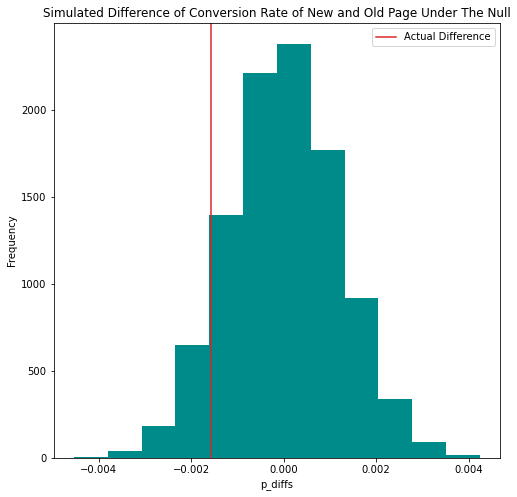

In [29]:
# convert our list to numpy array
p_diffs = np.asarray(p_diffs)
obs_diffs = conv_treatment - conv_control

plt.subplots(figsize=(8, 8))
plt.hist(p_diffs, color='darkcyan', bins=12)
plt.axvline(obs_diffs, color='tab:red', label="Actual Difference")
plt.xlabel('p_diffs')
plt.ylabel('Frequency')
plt.title('Simulated Difference of Conversion Rate of New and Old Page Under The Null')
plt.legend();

In [30]:
#calculate the greater proportion of both differences we've calculated above
(p_diffs > obs_diffs).mean()

0.9082

- We computed a proportion of **90%** of the p_diffs are greater than the actual observed difference in the dataset which is called the **p-value**.
- A p-value of **(0.9)** which is significantly larger than **(0.05)** means that:
>- The null hypothesis **cannot be rejected**.
>- Conversion rate will be **higher** in the null hypothesis and there is no difference between the new and old pages.
>- There is **no sufficient evidence** still that one page is better than the other in terms of a high conversion rate.

In [31]:
import statsmodels.api as sm

convert_old = len(df2.query('landing_page == "old_page" & converted == 1'))
convert_new = len(df2.query('landing_page == "new_page" & converted == 1'))
convert_old, convert_new, n_old, n_new

(17489, 17264, 145274, 145310)

In [32]:
z_score, p_value = sm.stats.proportions_ztest([convert_new, convert_old], [n_new, n_old], value=None, alternative='larger')
z_score, p_value

(-1.3109241984234394, 0.9050583127590245)

- In terms of the conversion rates of the old and new pages, they mean that we can't reject the null hypothesis and both pages are the same in conversion rate.
- **Yes**, these values agree with the previous values calculated above and both findings are matched.

<a id='regression'></a>
### Part III - A regression approach

**Logistic regression.**

In [33]:
#adding a dummy variable column and an intercept column of 1
df2[['ab_page', 'old_page']] = pd.get_dummies(df2['landing_page'], dtype=int)
df2['intercept'] = 1

In [34]:
reg_m = sm.Logit(df2['converted'], df2[['intercept', 'ab_page']])
results = reg_m.fit()

Optimization terminated successfully.
         Current function value: 0.366118
         Iterations 6


In [35]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290582
Method:                           MLE   Df Model:                            1
Date:                Tue, 21 Dec 2021   Pseudo R-squ.:               8.077e-06
Time:                        15:12:06   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1899
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9888      0.008   -246.669      0.000      -2.005      -1.973
ab_page       -0.0150      0.011     -1.311      0.190      -0.037       0.007
==============================================================================
"""

- The p-value here is **0.19** which is still higher than the significance level (0.05), so we can't reject the null in this model as well.
- P-value is different than the part**II** maybe because we performed a two-tailed test that is different than the regression model that includes dummy and intercept variables, nevertheless the findings are the same.

Considering other factors to add to our regression model could help us determine:
>- if there is other variables that could be influencing the conversion rate.
>- and can prevent the bias in our estimate as long as the factors added are relevant.<br><br>
- Also, adding multiple factors of different types to our model can make the model more complex and can lead to different problems such as multicollinearity or an over-fit model.

In [36]:
countries_df = pd.read_csv('./countries.csv')
df_new = countries_df.set_index('user_id').join(df2.set_index('user_id'), how='inner')

In [37]:
# show 5 rows of the new dataframe
df_new.head()

,country,timestamp,group,landing_page,converted,ab_page,old_page,intercept
user_id,,,,,,,,
834778,UK,2017-01-14 23:08:43.304998,control,old_page,0,0,1,1
928468,US,2017-01-23 14:44:16.387854,treatment,new_page,0,1,0,1
822059,UK,2017-01-16 14:04:14.719771,treatment,new_page,1,1,0,1
711597,UK,2017-01-22 03:14:24.763511,control,old_page,0,0,1,1
710616,UK,2017-01-16 13:14:44.000513,treatment,new_page,0,1,0,1


In [38]:
# view info of the country column before creating the dummy variables
df_new.country.value_counts()

US    203619
UK     72466
CA     14499
Name: country, dtype: int64

In [39]:
# Create the necessary dummy variables
df_new[['CA', 'UK', 'US']] = pd.get_dummies(df_new['country'], dtype=int)
df_new.head()

,country,timestamp,group,landing_page,converted,ab_page,old_page,intercept,CA,UK,US
user_id,,,,,,,,,,,
834778,UK,2017-01-14 23:08:43.304998,control,old_page,0,0,1,1,0,1,0
928468,US,2017-01-23 14:44:16.387854,treatment,new_page,0,1,0,1,0,0,1
822059,UK,2017-01-16 14:04:14.719771,treatment,new_page,1,1,0,1,0,1,0
711597,UK,2017-01-22 03:14:24.763511,control,old_page,0,0,1,1,0,1,0
710616,UK,2017-01-16 13:14:44.000513,treatment,new_page,0,1,0,1,0,1,0


In [40]:
# Fit our Linear Model and obtain the results
new_mod = sm.Logit(df_new['converted'], df_new[['intercept', 'UK', 'CA']])
result = new_mod.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.366116
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290581
Method:                           MLE   Df Model:                            2
Date:                Tue, 21 Dec 2021   Pseudo R-squ.:               1.521e-05
Time:                        15:12:08   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1984
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9967      0.007   -292.314      0.000      -2.010      -1.983
UK             0.0099      0.013      0.746      0.456      -0.016       0.036
CA            -0.0408      0.027     -1.518      0.129      -0.093       0.012
==============================================================================
"""

The country variable doesn't seem to have an effect on the conversion rate, as the p-value of each country is greater than 0.05 and we still can't reject the null.<br><br>
Now let's look at the interaction between page and country to see if there significant effects on conversion.

In [41]:
# add an interaction between page and country before fitting our final model
df_new['CA_page'] = df_new['CA'] * df_new['ab_page']
df_new['UK_page'] = df_new['UK'] * df_new['ab_page']
df_new.head()

,country,timestamp,group,landing_page,converted,ab_page,old_page,intercept,CA,UK,US,CA_page,UK_page
user_id,,,,,,,,,,,,,
834778,UK,2017-01-14 23:08:43.304998,control,old_page,0,0,1,1,0,1,0,0,0
928468,US,2017-01-23 14:44:16.387854,treatment,new_page,0,1,0,1,0,0,1,0,0
822059,UK,2017-01-16 14:04:14.719771,treatment,new_page,1,1,0,1,0,1,0,0,1
711597,UK,2017-01-22 03:14:24.763511,control,old_page,0,0,1,1,0,1,0,0,0
710616,UK,2017-01-16 13:14:44.000513,treatment,new_page,0,1,0,1,0,1,0,0,1


In [42]:
df_new['intercept'] = 1
final_mod = sm.Logit(df_new['converted'], df_new[['intercept', 'ab_page', 'CA', 'UK', 'CA_page', 'UK_page']])
result = final_mod.fit()
result.summary()

Optimization terminated successfully.
         Current function value: 0.366109
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              converted   No. Observations:               290584
Model:                          Logit   Df Residuals:                   290578
Method:                           MLE   Df Model:                            5
Date:                Tue, 21 Dec 2021   Pseudo R-squ.:               3.482e-05
Time:                        15:12:11   Log-Likelihood:            -1.0639e+05
converged:                       True   LL-Null:                   -1.0639e+05
Covariance Type:            nonrobust   LLR p-value:                    0.1920
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.9865      0.010   -206.344      0.000      -2.005      -1.968
ab_page       -0.0206      0.014     -1.505      0.132      -0.047       0.006
CA            -0.0175      0.038     -0.465      0.642      -0.091       0.056
UK            -0.0057      0.019     -0.306      0.760      -0.043       0.031
CA_page       -0.0469      0.054     -0.872      0.383      -0.152       0.059
UK_page        0.0314      0.027      1.181      0.238      -0.021       0.084
==============================================================================
"""

With these values we can confidently say that there is insufficient evidence that the landing page has an effect on the user conversion in each country,<br> since the **p-value** for each page/country interaction is **greater** than the significance level **(0.05)**.

<a id='conclusions'></a>
## Conclusions

>With this analysis, we figured that there is **no evidence** that the new landing page is better than the old in terms of whether the user converts or not and both pages has **the same conversion rate** as the null hypothesis states.<br><br>

>Also, the countries **don't seem to affect** the conversion rate of the user.<br><br>


>In this case, it would be more effective to create another landing page or take another approach to increase the users conversion rate.